<a href="https://colab.research.google.com/github/dokunoale/chagas/blob/feature%2FCNN/notebooks/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone --branch feature/CNN --single-branch https://github.com/dokunoale/chagas.git
%cd chagas
# Carica librerie installate
!pip install wfdb -q
!pip install gdown -q

# Aggiungi solo la root del progetto (src)
import sys
sys.path.append('/content/chagas/src')

# Importa tutto dai moduli
from preprocessing import tf_dataset_loader
from models import utils

# Importa simboli specifici (se vuoi)
from preprocessing.tf_dataset_loader import *
from models.utils import *

Cloning into 'chagas'...
remote: Enumerating objects: 147, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 147 (delta 26), reused 19 (delta 17), pack-reused 105 (from 1)
Receiving objects: 100% (147/147), 58.02 KiB | 2.32 MiB/s, done.
Resolving deltas: 100% (55/55), done.
/content/chagas
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 26.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.0 which is incompatible.
dask-cudf-cu12 25.2.2 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.0 which is incompatible.
cudf-cu12 25.2.1 requires pandas<2

In [3]:
import gdown

url = "https://drive.google.com/file/d/1RrxSAqML5xLWFSgilWLBv_X_H1vd04GG/view?usp=drive_link"
gdown.download(url, "dataset.zip", quiet=False, fuzzy=True)
!unzip -q dataset.zip -d ./dataset

Downloading...
From (original): https://drive.google.com/uc?id=1RrxSAqML5xLWFSgilWLBv_X_H1vd04GG
From (redirected): https://drive.google.com/uc?id=1RrxSAqML5xLWFSgilWLBv_X_H1vd04GG&confirm=t&uuid=824966b0-8884-4136-83c9-5a7aa66bd36b
To: /content/chagas/dataset.zip
100%|██████████| 332M/332M [00:03<00:00, 102MB/s]


In [4]:
#Carichiamo su array np
X_train_positive, y_train_positive = tf_dataset_loader.load_dataset('/content/chagas/dataset/splitted_dataset/train/positives')
X_train_negative, y_train_negative = tf_dataset_loader.load_dataset('/content/chagas/dataset/splitted_dataset/train/negatives')

X_val_positive, y_val_positive = tf_dataset_loader.load_dataset('/content/chagas/dataset/splitted_dataset/val/positives')
X_val_negative, y_val_negative = tf_dataset_loader.load_dataset('/content/chagas/dataset/splitted_dataset/val/negatives')

X_test_positive, y_test_positive = tf_dataset_loader.load_dataset('/content/chagas/dataset/splitted_dataset/test/positives')
X_test_negative, y_test_negative = tf_dataset_loader.load_dataset('/content/chagas/dataset/splitted_dataset/test/negatives')

In [5]:
print(f"TRAIN: {X_train_positive.shape[0]} positivi, {X_train_negative.shape[0]} negativi")
print(f"VAL: {X_val_positive.shape[0]} positivi, {X_val_negative.shape[0]} negativi")
print(f"TEST: {X_test_positive.shape[0]} positivi, {X_test_negative.shape[0]} negativi")

TRAIN: 2090 positivi, 2110 negativi
VAL: 300 positivi, 300 negativi
TEST: 610 positivi, 590 negativi


In [6]:
X_train, y_train = tf_dataset_loader.concatenate_and_shuffle((X_train_positive, y_train_positive), (X_train_negative, y_train_negative))
X_val, y_val = tf_dataset_loader.concatenate_and_shuffle((X_val_positive, y_val_positive), (X_val_negative, y_val_negative))
X_test, y_test = tf_dataset_loader.concatenate_and_shuffle((X_test_positive, y_test_positive), (X_test_negative, y_test_negative))

In [7]:
print(f"TRAIN SHAPE: {X_train.shape} - VALIDATION SHAPE: {X_val.shape} - TEST SHAPE: {X_test.shape}")

TRAIN SHAPE: (4200, 2800, 12) - VALIDATION SHAPE: (600, 2800, 12) - TEST SHAPE: (1200, 2800, 12)


In [8]:
y_train = y_train.astype(int)
y_val = y_val.astype(int)
y_test = y_test.astype(int)

# MODELLO CNN

In [9]:
from models import layers

In [23]:
!git pull origin feature/CNN
%cd /content/chagas/src/models

from models import utils
from utils import *
import importlib
import utils

importlib.reload(utils)

from models import build_CNN
from build_CNN import build_ecg_model_with_spectrogram
import importlib
import build_CNN

importlib.reload(build_CNN)

from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import AUC
from sklearn.utils import class_weight

From https://github.com/dokunoale/chagas
 * branch            feature/CNN -> FETCH_HEAD
Already up to date.
/content/chagas/src/models


In [24]:
model = build_CNN.build_ecg_model_with_spectrogram (dropout_rate=0.4)

#compiliamo il modello
model.compile(optimizer='adam',
              loss=BinaryCrossentropy(),
              metrics=['accuracy', AUC(name='auc')])

#addestriamo il modello
callback = make_callback("1_CNN")

history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=30,
                    batch_size=32,
                    callbacks=callback)


Epoch 1/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 897ms/step - accuracy: 0.5351 - auc: 0.5456 - loss: 1.0473
Epoch 1: val_auc improved from -inf to 0.34634, saving model to 1_CNN_best_model.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.5352 - auc: 0.5459 - loss: 1.0453 - val_accuracy: 0.5000 - val_auc: 0.3463 - val_loss: 0.6962 - learning_rate: 0.0010
Epoch 2/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 870ms/step - accuracy: 0.5757 - auc: 0.6105 - loss: 0.6590
Epoch 2: val_auc improved from 0.34634 to 0.79154, saving model to 1_CNN_best_model.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 146s 911ms/step - accuracy: 0.5760 - auc: 0.6109 - loss: 0.6588 - val_accuracy: 0.7233 - val_auc: 0.7915 - val_loss: 0.5625 - learning_rate: 0.0010
Epoch 3/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 869ms/step - accuracy: 0.6793 - auc: 0.7488 - loss: 0.5764
Epoch 3: val_auc improved from 0.79154 to 0.79894, saving model to 1_CNN_best_model.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 141s 903ms/step - accuracy: 0.6793 - auc: 0.748

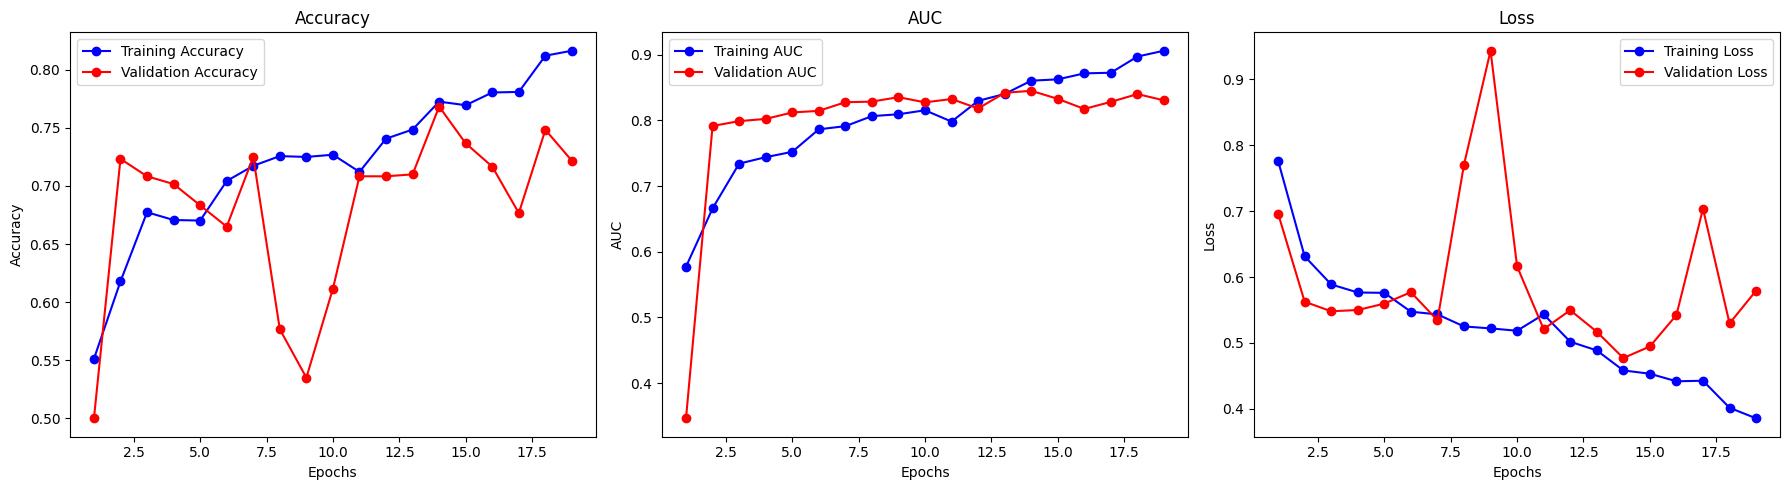

In [25]:
utils.plot_training_metrics(history)

In [29]:
#Facciamo le predizioni
y_pred_proba = model.predict(X_test).flatten()

#Troviamo la soglia ottimale
optimal_threshold = find_optimal_threshold(y_test, y_pred_proba)

# Applica soglia ottimale per binarizzare le predizioni
y_pred_binary = (y_pred_proba >= optimal_threshold).astype(int)

38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 224ms/step
Soglia ottimale: 0.509


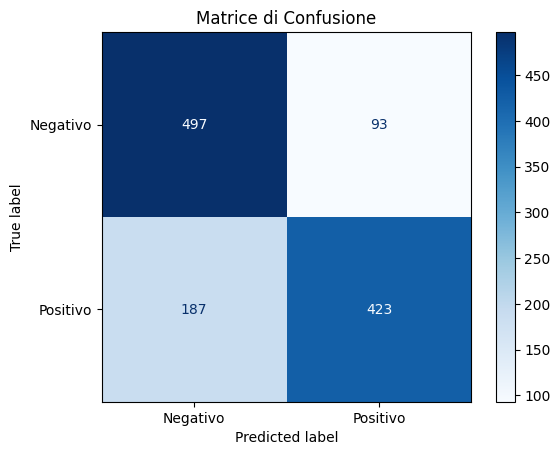

In [30]:
#Calcoliamo la matrice di confusione e la visualizziamo
cm = confusion_matrix(y_test, y_pred_binary)
show_confusion_matrix(cm)

Proviamo a trovare una soglia che diminuisca i falsi negativi

In [39]:
def find_threshold_for_min_recall(y_true, y_pred_proba, min_recall=0.8):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    valid_indices = [i for i, val in enumerate(tpr) if val >= min_recall]
    if not valid_indices:
        print("Nessuna soglia raggiunge la recall minima richiesta.")
        return None
    # Prendi la soglia con il più basso FPR tra quelli con recall >= min_recall
    best_idx = min(valid_indices, key=lambda i: fpr[i])
    threshold = thresholds[best_idx]
    print(f"Soglia con recall >= {min_recall}: {threshold:.3f}")
    return threshold

In [40]:
#Facciamo le predizioni
y_pred_proba = model.predict(X_test).flatten()

#Troviamo la soglia ottimale
optimal_threshold_min_rec = find_threshold_for_min_recall(y_test, y_pred_proba)

# Applica soglia ottimale per binarizzare le predizioni
y_pred_binary = (y_pred_proba >= optimal_threshold_min_rec).astype(int)

38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 186ms/step
Soglia con recall >= 0.8: 0.429


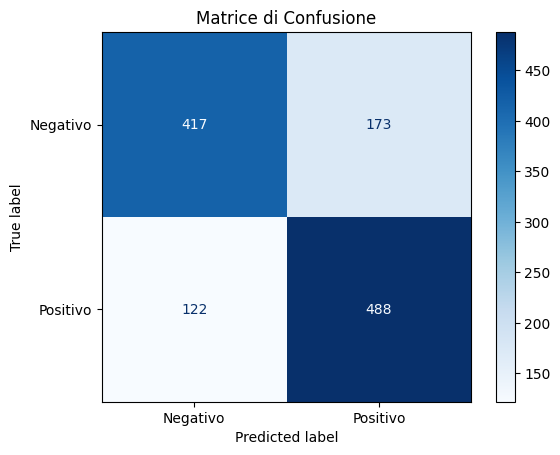

In [41]:
#Calcoliamo la matrice di confusione e la visualizziamo
cm = confusion_matrix(y_test, y_pred_binary)
show_confusion_matrix(cm)

In [35]:
#Vediamo i risultati
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

acc = accuracy_score(y_test, y_pred_binary)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {acc:.3f}")
print(f"AUC: {auc:.3f}")

class_report1 = classification_report(y_test, y_pred_binary, target_names=["Negativo", "Positivo"])
print(class_report1)
class_report1 = classification_report(y_test, y_pred_binary, output_dict=True )

Accuracy: 0.754
AUC: 0.841
              precision    recall  f1-score   support

    Negativo       0.77      0.71      0.74       590
    Positivo       0.74      0.80      0.77       610

    accuracy                           0.75      1200
   macro avg       0.76      0.75      0.75      1200
weighted avg       0.76      0.75      0.75      1200

